# Decision Analysis 1

## Promethee

The objective of this laboratory session is to gain practical understanding of the **PROMETHEE** method – one of the most important *outranking* methods used in Multi-Criteria Decision Analysis (MCDA).

The PROMETHEE method is designed to rank a finite set of decision alternatives evaluated with respect to multiple, often conflicting criteria. It is based on pairwise comparisons of alternatives and uses the concept of the degree to which one alternative outranks another.

Within the method, for each criterion, the difference in evaluations between two alternatives is calculated. This difference is then transformed using a preference function into a value in the interval ⟨0,1⟩, representing the degree to which alternative *a* is preferred over alternative *b*. The resulting partial preference values are weighted and aggregated into a global preference index using a weighted average.

The next step of the method is the computation of aggregated measures called preference flows:

- **positive flow (φ⁺)** – represents the strength with which a given alternative outranks the others,
- **negative flow (φ⁻)** – represents the strength with which other alternatives outrank the given alternative.

In the case of **PROMETHEE II**, an additional measure is calculated:

- **net flow (φ)** – defined as the difference between the positive and negative flows.

In PROMETHEE II, the final ranking is based on the net flow – the higher the value of φ, the better the position of the alternative in the ranking. In contrast, PROMETHEE I provides a partial ranking based on the comparison of positive and negative flows, which may result in incomparability between some alternatives.

In the PROMETHEE family of methods, the decision maker provides preference information in the following form:

- **q** – indifference threshold,
- **p** – strict preference threshold,
- **w** – weight of criterion *k*,
- direction of preference (cost or benefit criterion).

> **IMPORTANT**
>
> Code written in this notebook will be checked against automatic code checker and the points will be given based on its' results, please leave the function signatures unchanged.
> As a result there are no partial points for a programing tasks

In [103]:
from pathlib import Path

import numpy as np
import pandas as pd

import utils
from utils import display_ranking

In [104]:
# Loading dataset and preference information

# 2. Bierzemy próbkę 15 studentów i tylko wartości liczbowe do analizy PROMETHEE
dataset = pd.read_csv("dataset.csv")
dataset.index = dataset.name
dataset.drop(columns=["id", "name", "link"], inplace=True)


# 3. Tworzymy informacje o preferencjach (wagi, progi) dla tych 5 kryteriów
preference_information = pd.read_csv("preference.csv")
preference_information.index.name = "Criterion"

In [105]:
dataset

,price,year,mileage,power,fuel_consumption,appearance
name,,,,,,
Kia Venga,32500,2015,82000,125,7.6,4
Hyundai i20,36950,2014,71200,86,5.1,7
BMW 118d,33800,2014,180686,143,8.0,9
Renault Megane,37900,2016,135000,100,7.2,7
Nissan Qashqai,38700,2015,180000,130,6.2,6
Chevrolet Trax,34900,2014,97500,140,7.3,4
MINI Cooper S 60,49999,2015,71000,192,7.7,9
Toyota Yaris,41500,2015,119000,100,5.9,5
Seat Ibiza,30900,2016,156000,90,6.5,7


In [106]:
preference_information

,Criterion,q,p,v,w,type
Criterion,,,,,,
0,price,500.0,2000.0,8000.0,5,cost
1,year,0.0,1.0,NaN,2,gain
2,mileage,5000.0,20000.0,80000.0,4,cost
3,power,10.0,30.0,NaN,3,gain
4,fuel_consumption,0.3,1.0,3.0,4,cost
5,appearance,1.0,2.0,NaN,3,gain


### Task 1 (maximum points:  1)


Implement the `difference_function`. The function should calculate the difference between two alternatives with respect to a given criterion. The implementation must take into account the **criterion type**:

- for a **gain (maximization)** criterion:

  $d_k(a, b) = a − b$

- for a **cost (minimization)** criterion:

  $d(a, b) = b − a$

The function should return a single numeric value representing the difference used later in the marginal preference calculation.

In [107]:
# TODO
def difference_function(
    alternative_a: float, alternative_b: float, criterion_type: utils.CriterionType
) -> float:
    """
    Function that calculates the difference between given alternative pair on a single criterion.

    :param alternative_a: first alternative in a pair
    :param alternative_b: second alternative in a pair
    :param criterion_type: criterion type either gain or cost
    :return: difference between alternative pair calculated according to the criterion type
    """
    criterion_type = utils.CriterionType(criterion_type)
    if criterion_type == utils.CriterionType.GAIN:
        return alternative_a - alternative_b
    elif criterion_type == utils.CriterionType.COST:
        return alternative_b - alternative_a

### Task 2 (maximum points:  1)


Implement the `marginal_preference_function`, that should compute the normalized marginal preference value based on:

- the difference value `diff`,
- the indifference threshold `indifference_threshold` ($q_k$),
- the strict preference threshold `preference_threshold` ($p_k$).

For computation please use the following formula:
$$
    \pi_k (a, b) = \left\{ \begin{array}{ll}
    1, & \textrm{if } d_k(a, b) > p_k,\\
    0, & \textrm{if } d_k(a, b) \leq q_k,\\
    \frac{d_k(a, b) - q_k} {p_k - q_k}, & \textrm{if } q_k < d_k(a, b) \leq p_k.
    \end{array} \right.
$$

In [108]:
def marginal_preference_function(
    diff: float, indifference_threshold: float, preference_threshold: float
) -> float:
    """
    Function that calculates the marginal preference given a difference for a given thresholds.

    :param diff: difference between compared alternatives
    :param indifference_threshold: indifference threshold
    :param preference_threshold: preference threshold
    :return: float, representing the marginal preference index
    """
    if diff <= indifference_threshold:
        return 0.0
    elif diff >= preference_threshold:
        return 1.0
    else:
        return (diff - indifference_threshold) / (
            preference_threshold - indifference_threshold
        )

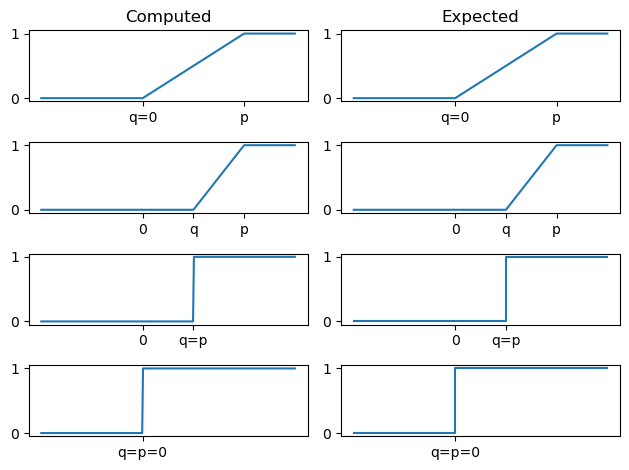

In [109]:
utils.test_marginal_preference_function(marginal_preference_function)

### Task 3 (maximum points:  1)


Implement the `calculate_marginal_preference_matrix` function.

The function should:

1. Compute the difference between every pair of alternatives for every criterion.
2. Apply the marginal preference function using the thresholds provided in `preference_information`.
3. Construct a 3-dimensional matrix containing marginal preference values for:
   - each pair of alternatives,
   - each criterion.

The output should be a NumPy array storing all marginal preference values.

In [110]:
def calculate_marginal_preference_matrix(
    dataset: pd.DataFrame, preference_information: pd.DataFrame
) -> np.ndarray:
    n = dataset.shape[0]
    m = preference_information.shape[0]
    matrix = np.zeros((n, n, m))

    # Wyciąganie nazw kryteriów
    if "Criterion" in preference_information.columns:
        crit_names = preference_information["Criterion"].tolist()
    elif "criterion" in preference_information.columns:
        crit_names = preference_information["criterion"].tolist()
    else:
        crit_names = preference_information.index.tolist()

    for k in range(m):
        crit_name = crit_names[k]
        row = preference_information.iloc[k]

        q = float(row["q"])
        p = float(row["p"])
        ctype = row["type"]

        if crit_name not in dataset.columns:
            col_name = dataset.columns[k]
        else:
            col_name = crit_name

        for i in range(n):
            for j in range(n):
                # PRAWIDŁOWY, bezpieczny sposób pobierania komórki
                a = float(dataset[col_name].iloc[i])
                b = float(dataset[col_name].iloc[j])

                diff = difference_function(a, b, ctype)
                matrix[i, j, k] = marginal_preference_function(diff, q, p)

    return matrix

In [111]:
marginal_preference_matrix = calculate_marginal_preference_matrix(
    dataset, preference_information
)

In [112]:
marginal_preference_matrix[4, 5]

array([0., 1., 0., 0., 1., 1.])

### Task 4 (maximum points:  1)


Implement the `calculate_comprehensive_preference_index` function.

The function should aggregate marginal preference values across all criteria using criterion weights.

For each pair of alternatives (a, b), compute the comprehensive preference index:

$$\pi(a, b) = \frac{\sum w_k * \pi_k(a, b)}{\sum w_k}$$

where:
- $w_k$ is the weight of criterion k,
- $\pi_k(a, b)$ is the marginal preference value.

In [113]:
# TODO
def calculate_comprehensive_preference_index(
    marginal_preference_matrix: np.ndarray, preference_information: pd.DataFrame
) -> np.ndarray:
    """
    Function that calculates comprehensive preference index for the given dataset

    :param marginal_preference_matrix: 3D numpy array with marginal preference matrix on every parser, Consecutive indices [i, j, k] describe first alternative, second alternative, criterion
    :param preference_information: Padnas dataframe containing preference information
    :return: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    """
    weights = preference_information["w"].values
    return np.sum(marginal_preference_matrix * weights, axis=2) / np.sum(weights)

In [114]:
comprehensive_preference_index = calculate_comprehensive_preference_index(
    marginal_preference_matrix, preference_information
)

In [115]:
comprehensive_preference_index

array([[0.        , 0.47619048, 0.4399093 , 0.53571429, 0.42857143,
        0.46666667, 0.23809524, 0.53571429, 0.33333333, 0.3015873 ,
        0.44444444, 0.42857143, 0.42857143, 0.46412698, 0.41857143],
       [0.40698413, 0.        , 0.38095238, 0.45238095, 0.57936508,
        0.52380952, 0.42857143, 0.70748299, 0.38095238, 0.10973243,
        0.27210884, 0.61904762, 0.38095238, 0.73619048, 0.33333333],
       [0.2       , 0.52380952, 0.        , 0.52380952, 0.40238095,
        0.23809524, 0.23809524, 0.52380952, 0.28571429, 0.28571429,
        0.28571429, 0.33095238, 0.41033651, 0.54421769, 0.28571429],
       [0.26530612, 0.12380952, 0.42176871, 0.        , 0.33333333,
        0.23809524, 0.3877551 , 0.47619048, 0.19047619, 0.        ,
        0.        , 0.33333333, 0.19047619, 0.50793651, 0.23809524],
       [0.33333333, 0.23809524, 0.28571429, 0.33333333, 0.        ,
        0.42857143, 0.42857143, 0.38095238, 0.14285714, 0.14285714,
        0.14285714, 0.29251701, 0.22857143, 

### Task 5 (maximum points:  1)


Implement three functions:

- `calculate_positive_flow`
- `calculate_negative_flow`
- `calculate_net_flow`

Positive flow (φ⁺):
Represents how strongly a given alternative outranks the others.
It is calculated as the average of preference indices in the corresponding row of the comprehensive preference matrix.

Negative flow (φ⁻):
Represents how strongly a given alternative is outranked by others.
It is calculated as the average of preference indices in the corresponding column.

Net flow (φ):
φ = φ⁺ − φ⁻

Each function should return a pandas Series indexed by alternatives.

In [116]:
# TODO
def calculate_positive_flow(
    comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index
) -> pd.Series:
    """
    Function that calculates the positive flow value for the given preference matrix and corresponding index

    :param comprehensive_preference_matrix: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    :param alternatives: index representing the alternative name in the corresponding position in preference matrix
    :return: series representing positive flow values for the given preference matrix
    """
    n = len(alternatives)
    pos_flow = np.sum(comprehensive_preference_matrix, axis=1) / (n - 1)
    return pd.Series(pos_flow, index=alternatives)

In [117]:
# TODO
def calculate_negative_flow(
    comprehensive_preference_matrix: np.ndarray, alternatives: pd.Index
) -> pd.Series:
    """
    Function that calculates the negative flow value for the given preference matrix and corresponding index

    :param comprehensive_preference_matrix: 2D numpy array with marginal preference matrix. Every entry in the matrix [i, j] represents comprehensive preference index between alternative i and alternative j
    :param alternatives: index representing the alternative name in the corresponding position in preference matrix
    :return: series representing negative flow values for the given preference matrix
    """
    n = len(alternatives)
    neg_flow = np.sum(comprehensive_preference_matrix, axis=0) / (n - 1)
    return pd.Series(neg_flow, index=alternatives)

In [118]:
# TODO
def calculate_net_flow(positive_flow: pd.Series, negative_flow: pd.Series) -> pd.Series:
    """
    Function that calculates the net flow value for the given positive and negative flow

    :param positive_flow: series representing positive flow values for the given preference matrix
    :param negative_flow: series representing negative flow values for the given preference matrix
    :return: series representing net flow values for the given preference matrix
    """
    return positive_flow - negative_flow

In [119]:
positive_flow = calculate_positive_flow(comprehensive_preference_index, dataset.index)
negative_flow = calculate_negative_flow(comprehensive_preference_index, dataset.index)
net_flow = calculate_net_flow(positive_flow, negative_flow)

In [120]:
positive_flow

name
Kia Venga           0.424291
Hyundai i20         0.450847
BMW 118d            0.362740
Renault Megane      0.264755
Nissan Qashqai      0.271914
Chevrolet Trax      0.328618
MINI Cooper S 60    0.450177
Toyota Yaris        0.221445
Seat Ibiza          0.473113
Renault Clio        0.488963
Skoda Fabia         0.414739
Renault Captur      0.329984
Ford Focus          0.350867
Nissan Juke         0.335057
Honda Jazz          0.390810
dtype: float64

In [121]:
negative_flow

name
Kia Venga           0.305372
Hyundai i20         0.307256
BMW 118d            0.423712
Renault Megane      0.453102
Nissan Qashqai      0.437715
Chevrolet Trax      0.414143
MINI Cooper S 60    0.398834
Toyota Yaris        0.495249
Seat Ibiza          0.302235
Renault Clio        0.154017
Skoda Fabia         0.246965
Renault Captur      0.424077
Ford Focus          0.408772
Nissan Juke         0.487267
Honda Jazz          0.299603
dtype: float64

In [ ]:
net_flow

name
Kia Venga           0.118918
Hyundai i20         0.143591
BMW 118d           -0.060972
Renault Megane     -0.188346
Nissan Qashqai     -0.165800
Chevrolet Trax     -0.085525
MINI Cooper S 60    0.051343
Toyota Yaris       -0.273805
Seat Ibiza          0.170878
Renault Clio        0.334945
Skoda Fabia         0.167775
Renault Captur     -0.094093
Ford Focus         -0.057905
Nissan Juke        -0.152211
Honda Jazz          0.091207
dtype: float64


### Task 6 (maximum points:  1)


Implement the `create_partial_ranking` function. The function should construct a partial ranking according to PROMETHEE I methodology, using:

- positive flow (φ⁺),
- negative flow (φ⁻).

The ranking should reflect dominance relations based on comparisons of positive and negative flows.

$$
    \text{a is preferred over b (a is higher in the ranking)} \Longleftrightarrow
    \begin{cases}
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b) \text{, or} \\
        \phi^+(a) = \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b) \text{, or} \\
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) = \phi^-(b)
    \end{cases}
$$


$$
     \text{a is indifferent with b (a is higher in the ranking)} \Longleftrightarrow
    \phi^+(a) = \phi^+(b) \text{ and } \phi^-(a) = \phi^-(b)
$$

$$
    \text{a is incomparable with b} \Longleftrightarrow
    \begin{cases}
        \phi^+(a) > \phi^+(b) \text{ and } \phi^-(a) > \phi^-(b) \text{, or} \\
        \phi^+(a) < \phi^+(b) \text{ and } \phi^-(a) < \phi^-(b)
    \end{cases}
$$

The function should return a DataFrame where in index and columns are alternatives and cell indicate:
- 1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
- 0- otherwise

In [123]:
# TODO
def create_partial_ranking(
    positive_flow: pd.Series, negative_flow: pd.Series
) -> pd.DataFrame:
    """
    Function that aggregates positive and negative flow to a partial ranking (from Promethee I)

    :param positive_flow: series representing positive flow values for the given preference matrix
    :param negative_flow: series representing negative flow values for the given preference matrix
    :return: partial ranking in a form of outranking matrix, as Dataframe where in index and columns are alternatives, i.e.
    1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
    0- otherwise
    """
    matrix = pd.DataFrame(0, index=positive_flow.index, columns=positive_flow.index)
    for i in positive_flow.index:
        for j in positive_flow.index:
            p_i, p_j = positive_flow[i], positive_flow[j]
            n_i, n_j = negative_flow[i], negative_flow[j]

            if (
                (p_i > p_j and n_i < n_j)
                or (p_i == p_j and n_i < n_j)
                or (p_i > p_j and n_i == n_j)
                or (p_i == p_j and n_i == n_j)
            ):
                matrix.loc[i, j] = 1
    return matrix

### Task 7 (maximum points:  1)


Implement the `create_complete_ranking` function.

The function should create a complete ranking according to PROMETHEE II methodology, based solely on the net flow (φ).

Alternatives should be sorted in descending order of net flow:
- higher φ → better rank.

The function should return a DataFrame where in index and columns are alternatives and cell indicate:
- 1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
- 0- otherwise

In [124]:
# TODO
def create_complete_ranking(net_flow: pd.Series) -> pd.DataFrame:
    """
    Function that aggregates positive and negative flow to a complete ranking (from Promethee II)
    :param net_flow: series representing net flow values for the given preference matrix
    :return: complete ranking in a form of outranking matrix, as Dataframe where in index and columns are alternatives, i.e.
    1- if for the give pair [i, j] the alternative i is preferred over j or i is indifferent from j
    0- otherwise
    """
    matrix = pd.DataFrame(0, index=net_flow.index, columns=net_flow.index)
    for i in net_flow.index:
        for j in net_flow.index:
            if net_flow[i] >= net_flow[j]:
                matrix.loc[i, j] = 1
    return matrix

In [125]:
partial_ranking = create_partial_ranking(positive_flow, negative_flow)
complete_ranking = create_complete_ranking(net_flow)

/var/folders/m6/kqz4y1y10tgg9qzy55r86src0000gn/T/ipykernel_90836/4181836099.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


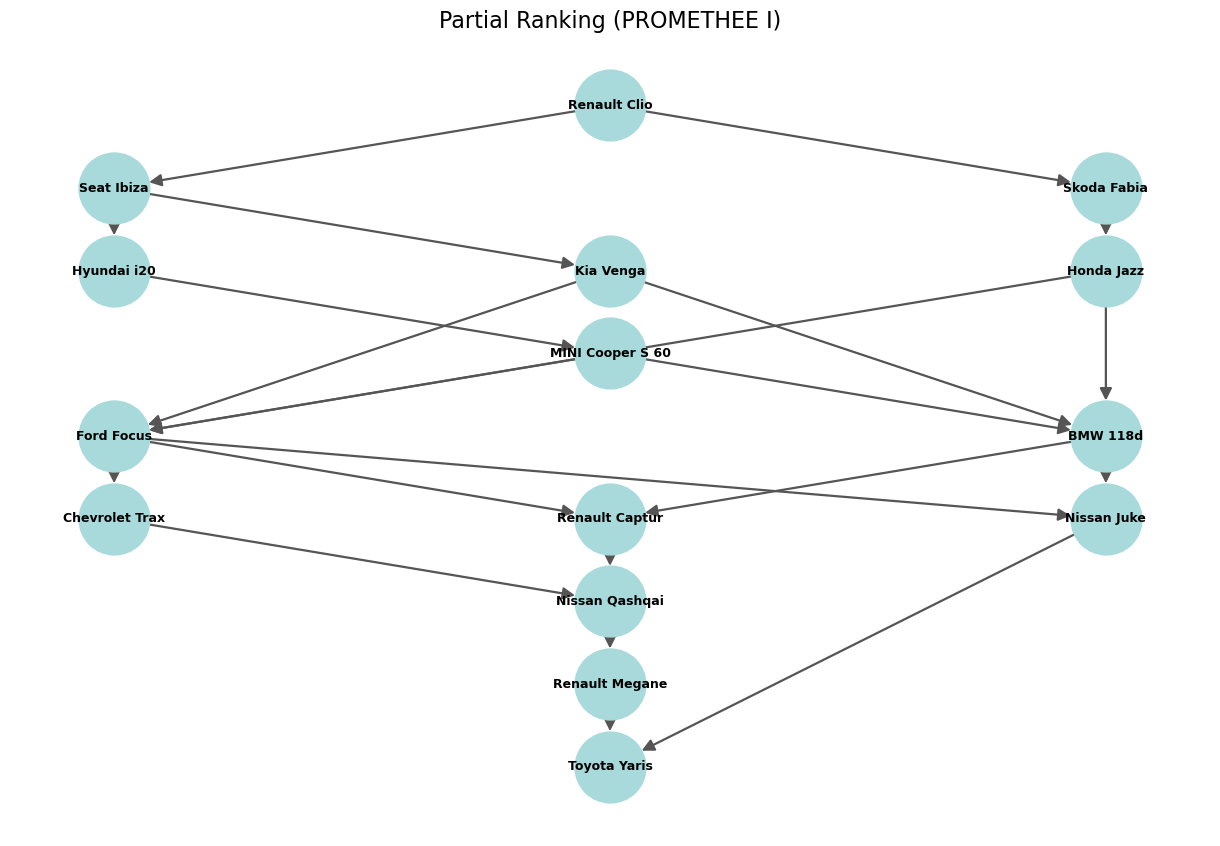

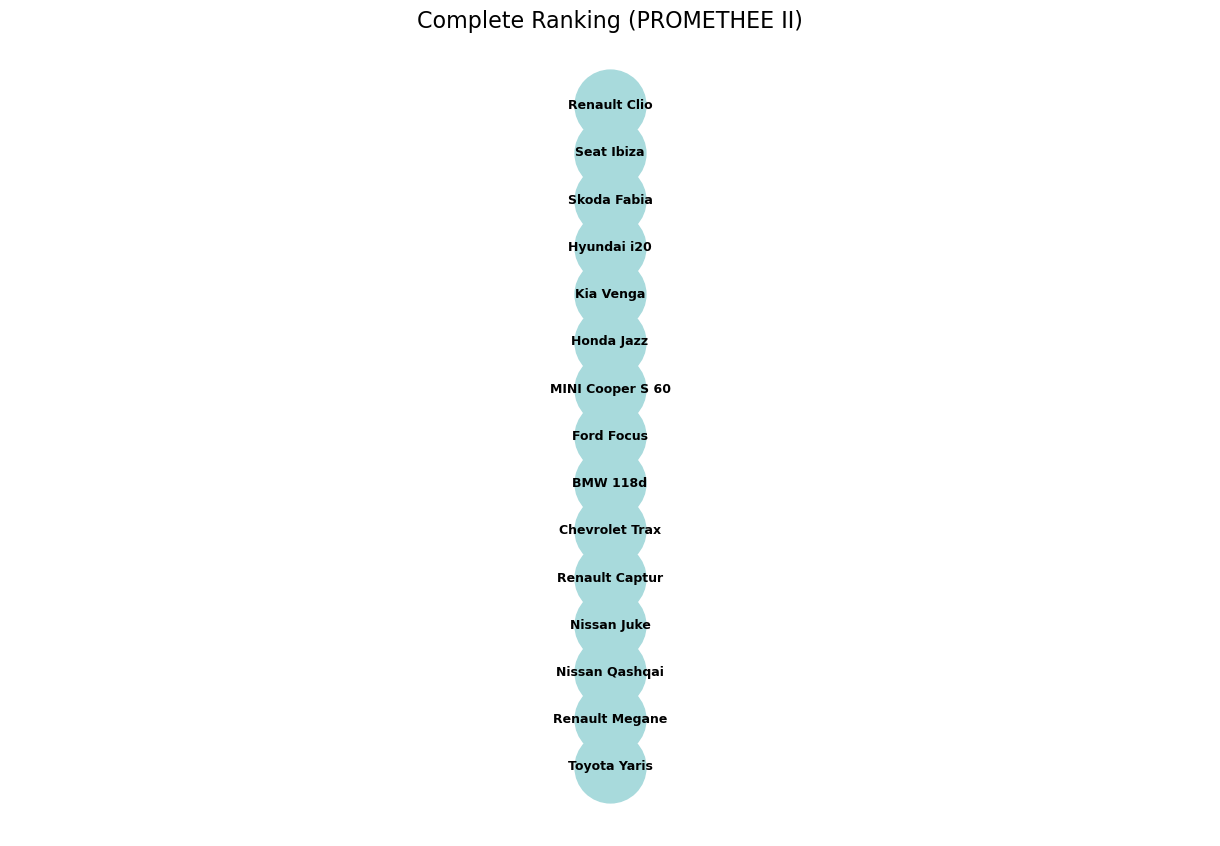

In [126]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def safe_display_ranking(ranking_df, title):
    # Build a strict-preference graph: edge a -> b means "a is strictly better than b"
    alternatives = list(ranking_df.index)
    G = nx.DiGraph()
    G.add_nodes_from(alternatives)

    for a in alternatives:
        for b in alternatives:
            if a == b:
                continue
            if ranking_df.loc[a, b] == 1 and ranking_df.loc[b, a] == 0:
                G.add_edge(a, b)

    # If possible, simplify to a Hasse-like diagram (fewer redundant edges)
    if nx.is_directed_acyclic_graph(G) and G.number_of_edges() > 0:
        G = nx.transitive_reduction(G)

    # Layer assignment: best nodes (not outranked by any node in G) are at level 0
    if nx.is_directed_acyclic_graph(G):
        level = {node: 0 for node in G.nodes}
        for node in nx.topological_sort(G):
            for child in G.successors(node):
                level[child] = max(level[child], level[node] + 1)
    else:
        # Fallback for any cyclic/tied structure: rank by row dominance score
        scores = ranking_df.sum(axis=1).sort_values(ascending=False)
        unique_scores = sorted(scores.unique(), reverse=True)
        score_to_level = {score: i for i, score in enumerate(unique_scores)}
        level = {node: score_to_level[scores[node]] for node in alternatives}

    # Manual top-down layered layout
    layers = {}
    for node, lev in level.items():
        layers.setdefault(lev, []).append(node)

    pos = {}
    for lev in sorted(layers):
        nodes = sorted(layers[lev], key=lambda n: ranking_df.loc[n].sum(), reverse=True)
        count = len(nodes)
        xs = np.linspace(-1, 1, count) if count > 1 else np.array([0.0])
        y = -lev
        for x, node in zip(xs, nodes):
            pos[node] = (x, y)

    plt.figure(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2600,
        node_color="#a8dadc",
        font_size=9,
        font_weight="bold",
        arrows=True,
        arrowsize=18,
        edge_color="#555555",
        width=1.6,
    )

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


safe_display_ranking(partial_ranking, "Partial Ranking (PROMETHEE I)")
safe_display_ranking(complete_ranking, "Complete Ranking (PROMETHEE II)")